# Student Performance Prediction & Explainability System

## Overview
An end-to-end machine learning pipeline to predict student academic performance 
across 5 grade classes using behavioural and demographic features. 
Models trained: Logistic Regression, Random Forest, XGBoost.
Explainability layer built using SHAP to identify key predictors.

**Dataset:** Students Performance Dataset — Kaggle (Rabie El Kharoua)  
**Target:** GradeClass (0=A, 1=B, 2=C, 3=D, 4=F)

## 1. Importing Libraries
Standard ML stack: Pandas and NumPy for data handling, 
Matplotlib and Seaborn for visualization, 
Scikit-learn for preprocessing and modelling, 
XGBoost for gradient boosting, SHAP for explainability.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


## 2. Loading the Dataset
Loading the CSV and inspecting shape, data types, and first few rows 
to understand the structure before any processing.

In [2]:
db = pd.read_csv("Student_performance_data _.csv")

In [3]:
print("Output")
print(db.head())

Output
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1          

print the details of every column its data type, Not-Null Count,column name

## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Inspection
Checking for missing values, duplicates, and data types across all columns.

In [4]:
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


print the number of null values in each column

# Objective
convert every heading to capital for better accessing

In [5]:
db.columns = db.columns.str.upper()

## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Inspection
Checking for missing values, duplicates, and data types across all columns.

In [6]:
print(db.isnull().sum())
print("-----------------------------------------------")
print("Duplicate Values", db.duplicated().sum())

STUDENTID            0
AGE                  0
GENDER               0
ETHNICITY            0
PARENTALEDUCATION    0
STUDYTIMEWEEKLY      0
ABSENCES             0
TUTORING             0
PARENTALSUPPORT      0
EXTRACURRICULAR      0
SPORTS               0
MUSIC                0
VOLUNTEERING         0
GPA                  0
GRADECLASS           0
dtype: int64
-----------------------------------------------
Duplicate Values 0


# Key Observation
- There are no null values in any column
- there are no duplicate entries in the dataset

describe each column using different aspacts

In [7]:
db.describe()

,STUDENTID,AGE,GENDER,ETHNICITY,PARENTALEDUCATION,STUDYTIMEWEEKLY,ABSENCES,TUTORING,PARENTALSUPPORT,EXTRACURRICULAR,SPORTS,MUSIC,VOLUNTEERING,GPA,GRADECLASS
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


# Objective

plot a histogram of the data based on GPA to check the average GPA distribution
data is plot on 0.5 GPA gaps 

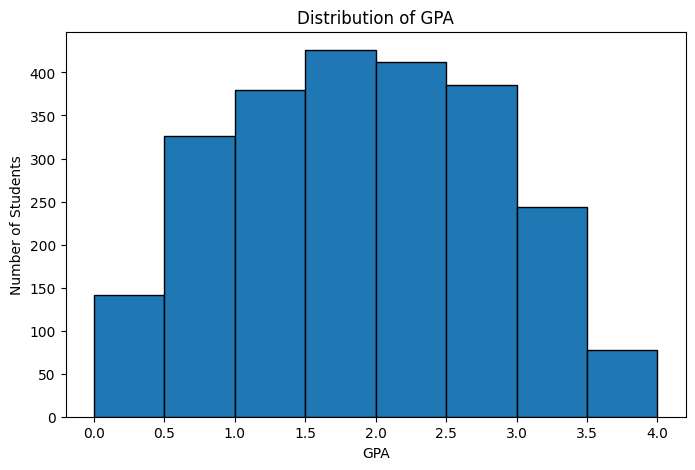

In [8]:
plt.figure(figsize=(8,5))
plt.hist(db["GPA"], bins = 8, edgecolor="black")
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.show()

# Key Observation
- Data is concentrated towards centre and is not skewed at either side
- maximum student have GPA between 1.5 to 2.0
- there are minimum student who have GPA greater than 3.5

### 3.2 Correlation Analysis
Computing pairwise correlations between all numeric features.
Note: GradeClass runs 0 (A) to 4 (F), so positive correlation 
means association with worse performance.

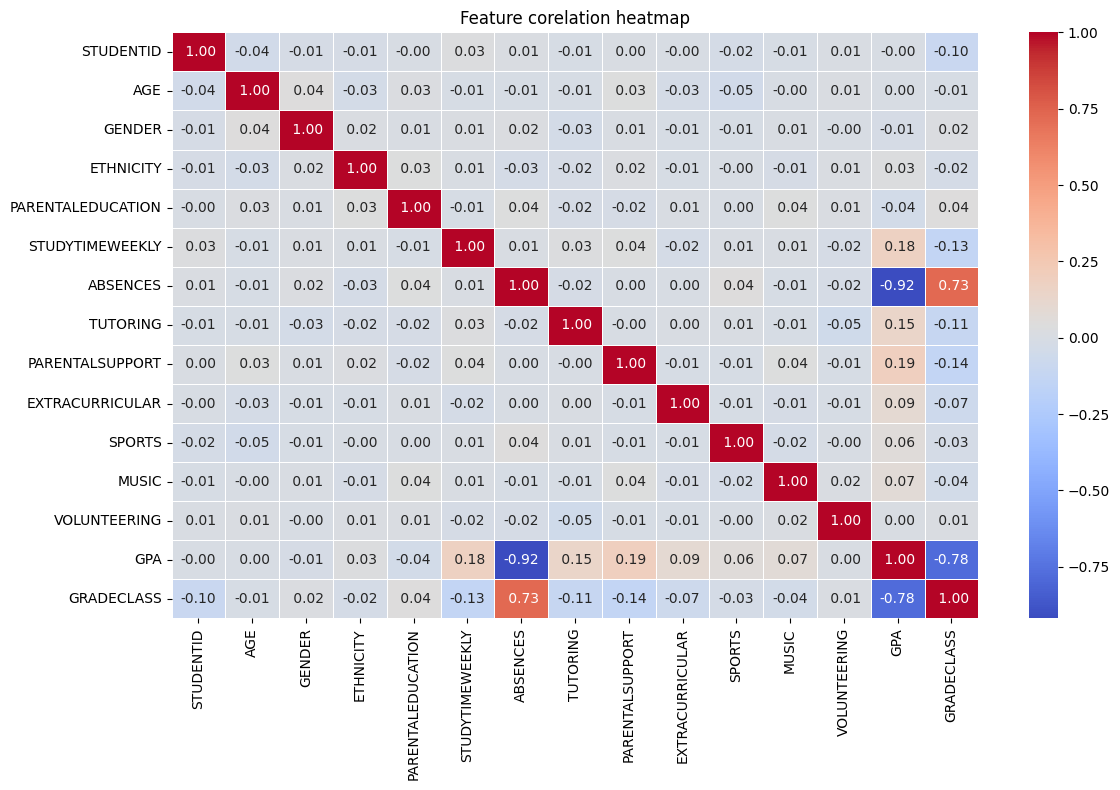

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(
    db.corr(),
    annot=True,
    fmt = " .2f",
    cmap="coolwarm",
    linewidths= 0.5
)
plt.title('Feature corelation heatmap')
plt.tight_layout()
plt.savefig("Corelation_heatmap.png", dpi = 150)
plt.show()


In [10]:
target_col = 'GRADECLASS'
correlations = db.corr()[target_col].drop(target_col)
print(correlations.sort_values(ascending=False))

ABSENCES             0.728633
PARENTALEDUCATION    0.041031
GENDER               0.022998
VOLUNTEERING         0.013156
AGE                 -0.006250
ETHNICITY           -0.023326
SPORTS              -0.026654
MUSIC               -0.036065
EXTRACURRICULAR     -0.069733
STUDENTID           -0.098500
TUTORING            -0.111695
STUDYTIMEWEEKLY     -0.134131
PARENTALSUPPORT     -0.136823
GPA                 -0.782835
Name: GRADECLASS, dtype: float64


### 3.3 Key EDA Findings
- **Absences** (r = +0.73): Strongest predictor — high absenteeism strongly associated with GradeClass 4 (F)
- **GPA** (r = -0.78): Removed — GradeClass is directly derived from GPA (data leakage)
- **Result** (r = +0.52): Removed — derived from GradeClass (data leakage)
- **Demographic features** (Gender, Age, Ethnicity): Near-zero correlation — minimal predictive value

## 4. Feature Engineering & Data Leakage Removal
Dropping columns that would cause data leakage:
- GradeClass → target variable (moved to testing)
- GPA → directly derives GradeClass
- Result → derived from GradeClass  
- StudentID → meaningless identifier

Final feature set: 12 behavioural and demographic columns.

In [11]:
training_model = db.drop(columns=['STUDENTID', 'GRADECLASS', 'GPA'])
Testing = db['GRADECLASS']

print(training_model.shape)
print(training_model.columns)


(2392, 12)
Index(['AGE', 'GENDER', 'ETHNICITY', 'PARENTALEDUCATION', 'STUDYTIMEWEEKLY',
       'ABSENCES', 'TUTORING', 'PARENTALSUPPORT', 'EXTRACURRICULAR', 'SPORTS',
       'MUSIC', 'VOLUNTEERING'],
      dtype='str')


## 5. Train-Test Split
80/20 split with random_state=42 for reproducibility.
Stratification not applied — class imbalance handled via class_weight='balanced' during training.

In [12]:
training_model_train, training_model_test, Testing_train, Testing_test = train_test_split(
    training_model, Testing, test_size= 0.25, random_state= 42
)
print(training_model_train.shape, training_model_test.shape)

(1794, 12) (598, 12)


## 6. Class Distribution Analysis
Checking target variable balance before modelling.
Heavy imbalance expected given real-world grade distributions.

In [13]:
print(Testing.value_counts())
print(Testing.value_counts(normalize=True).round(2))

GRADECLASS
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64
GRADECLASS
4.0    0.51
3.0    0.17
2.0    0.16
1.0    0.11
0.0    0.04
Name: proportion, dtype: float64


### Finding
Dataset is significantly imbalanced — 51% GradeClass 4 (F).
A naive model predicting F every time would achieve 51% accuracy.
**Therefore F1-score and ROC-AUC are used as primary evaluation metrics, not accuracy.**

## 7. Feature Scaling
Applying StandardScaler to normalize feature ranges.
Critical: Scaler fitted on training data only, then applied to test data 
to prevent data leakage from test set statistics.

In [14]:
scaler = StandardScaler()

training_model_train_scaled = scaler.fit_transform(training_model_train)
training_model_test_scaled = scaler.transform(training_model_test)

print("training_model_train_scaled: ", training_model_train_scaled)
print("training_model_test_scaled: ", training_model_test_scaled)

training_model_train_scaled:  [[-0.40981171 -1.02827012 -0.84340457 ... -0.6588268   2.00980741
  -0.42640143]
 [ 0.48242398  0.9725071   0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]
 [-0.40981171  0.9725071  -0.84340457 ... -0.6588268  -0.49756011
  -0.42640143]
 ...
 [-0.40981171  0.9725071  -0.84340457 ...  1.5178496  -0.49756011
  -0.42640143]
 [ 1.37465967 -1.02827012  2.07194765 ... -0.6588268  -0.49756011
  -0.42640143]
 [ 1.37465967 -1.02827012  0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]]
training_model_test_scaled:  [[-1.3020474   0.9725071   1.10016358 ...  1.5178496   2.00980741
   2.34520788]
 [-0.40981171  0.9725071  -0.84340457 ... -0.6588268  -0.49756011
   2.34520788]
 [-1.3020474  -1.02827012 -0.84340457 ... -0.6588268  -0.49756011
   2.34520788]
 ...
 [-1.3020474   0.9725071   0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]
 [-0.40981171 -1.02827012  0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]
 [-0.40981171 -1.02827012  2.07194765 .

## 8. Model Training & Evaluation

### 8.1 Logistic Regression (Baseline)
Linear model used as baseline. class_weight='balanced' to handle class imbalance.
Expected to underperform on non-linear relationships.

In [15]:
lr_model = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(training_model_train_scaled, Testing_train)

lr_pred = lr_model.predict(training_model_test_scaled)


In [16]:
accuracy = accuracy_score(Testing_test, lr_pred)
print("accuracy", accuracy*100)
print(classification_report(Testing_test, lr_pred))

accuracy 58.19397993311036
              precision    recall  f1-score   support

         0.0       0.13      0.36      0.19        28
         1.0       0.30      0.26      0.28        68
         2.0       0.44      0.34      0.39       105
         3.0       0.43      0.53      0.47       104
         4.0       0.92      0.78      0.85       293

    accuracy                           0.58       598
   macro avg       0.44      0.46      0.43       598
weighted avg       0.64      0.58      0.60       598



logistic regression marks a accuracy of 58.19% with a weighted f1-score of 0.60. the model performs well on majority class but less precise with minority class (4.0 >50% of dataset and precision of 92%). this suggest the linear decision boundaries are insufficient for the complex analysis of student grade

### 8.2 Random Forest
Ensemble of 100 decision trees. Handles non-linearity well.
class_weight='balanced' applied. No scaling required for tree-based models.

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(training_model_train,Testing_train)
rf_predict = rf_model.predict(training_model_test)


In [18]:
print("Accuracy: ", accuracy_score(Testing_test, rf_predict))
print(classification_report(Testing_test,rf_predict))

Accuracy:  0.68561872909699
              precision    recall  f1-score   support

         0.0       0.33      0.18      0.23        28
         1.0       0.47      0.49      0.48        68
         2.0       0.52      0.51      0.52       105
         3.0       0.51      0.59      0.55       104
         4.0       0.89      0.88      0.88       293

    accuracy                           0.69       598
   macro avg       0.54      0.53      0.53       598
weighted avg       0.68      0.69      0.68       598



### 8.3 XGBoost
Gradient boosting model. Generally strongest performer on tabular data.
Configured for multiclass classification with 5 output classes.

In [19]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    objective = 'multi:softmax',
    num_class = 5,
    random_state = 42,
    eval_metric = 'logloss'
)
xgb_model.fit(training_model_train,Testing_train)

xgb_pred = xgb_model.predict(training_model_test)

In [20]:
print("accuracy", accuracy_score(Testing_test, xgb_pred))
print(classification_report(Testing_test, xgb_pred))

accuracy 0.6906354515050167
              precision    recall  f1-score   support

         0.0       0.55      0.21      0.31        28
         1.0       0.46      0.41      0.43        68
         2.0       0.50      0.53      0.52       105
         3.0       0.54      0.49      0.51       104
         4.0       0.85      0.93      0.89       293

    accuracy                           0.69       598
   macro avg       0.58      0.52      0.53       598
weighted avg       0.68      0.69      0.68       598



In [21]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(Testing_test, classes=[0,1,2,3,4])

xgb_proba = xgb_model.predict_proba(training_model_test)
xgb_auc = roc_auc_score(y_test_bin, xgb_proba, multi_class='ovr', average='macro')
print(f"XGBoost ROC-AUC: {xgb_auc:.3f}")


rf_proba = rf_model.predict_proba(training_model_test)
rf_auc = roc_auc_score(y_test_bin, rf_proba, multi_class='ovr', average='macro')
print(f"Fandom forest ROC-AUC: {rf_auc:.3f}")


XGBoost ROC-AUC: 0.853
Fandom forest ROC-AUC: 0.854


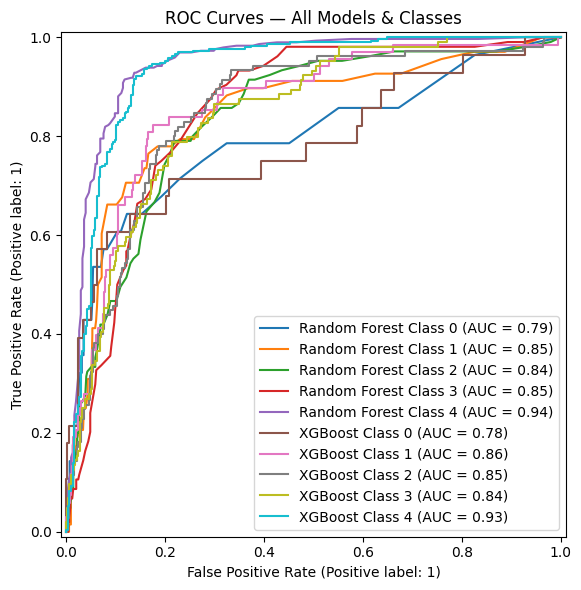

In [22]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_test_bin = label_binarize(Testing_test, classes=[0,1,2,3,4])

fig, ax = plt.subplots(figsize=(8,6))

for model, proba, name in [
    (rf_model, rf_model.predict_proba(training_model_test), 'Random Forest'),
    (xgb_model, xgb_model.predict_proba(training_model_test), 'XGBoost')
]:
    for i, cls in enumerate([0,1,2,3,4]):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            proba[:, i],
            name=f"{name} Class {cls}",
            ax=ax
        )

ax.set_title("ROC Curves — All Models & Classes")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

## 9. Model Comparison

### 9.1 Confusion Matrices
Visualizing prediction errors across all 5 grade classes for each model.
Strong diagonal = good predictions. Off-diagonal = misclassifications.

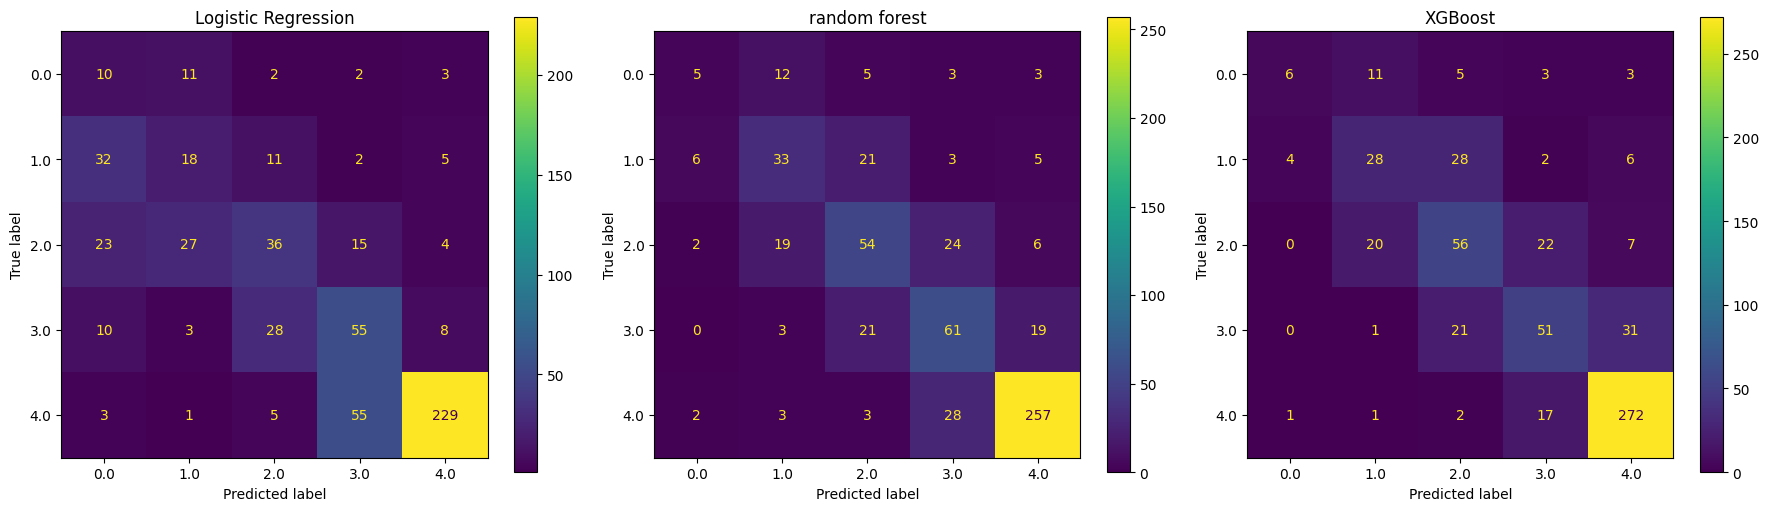

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1,3,figsize = (18,5))
for ax, model, preds, title in zip(
    axes,
    [lr_model, rf_model, xgb_model],
    [lr_pred, rf_predict, xgb_pred],
    ['Logistic Regression', 'random forest', 'XGBoost']
):
    ConfusionMatrixDisplay.from_predictions(Testing_test, preds, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi = 150)
plt.show()

### 9.2 Results Summary

| Model | Accuracy | Macro F1 | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 58% | 0.43 | — |
| Random Forest | 68.6% | 0.53 | 0.854 |
| XGBoost | 69.1% | 0.53 | 0.853 |

**Best model: XGBoost** — highest accuracy and strongest performance on minority classes.
ROC-AUC of 0.853 indicates strong class separation on an imbalanced 5-class problem.

## 10. Model Explainability — SHAP Analysis
Using SHAP (SHapley Additive exPlanations) to interpret XGBoost predictions.
SHAP assigns each feature a contribution value for every individual prediction,
enabling both global and local explainability.

In [24]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(training_model_test)
print(type(shap_values))


c:\Users\golch\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'numpy.ndarray'>


In [25]:
import numpy as np
print(np.array(shap_values).shape)


(598, 12, 5)


<function matplotlib.pyplot.show(close=None, block=None)>

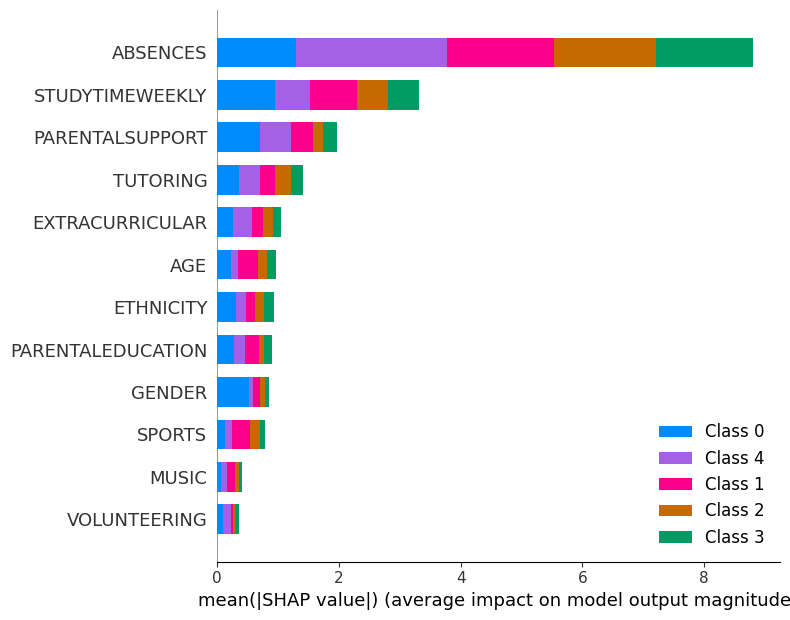

In [26]:
shap.summary_plot(
    shap_values,
    training_model_test,
    feature_names = training_model_test.columns,
    plot_type ="bar",
    show = False
    )
plt.tight_layout()
plt.savefig("summary_plot.png", dpi = 300, bbox_inches="tight")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

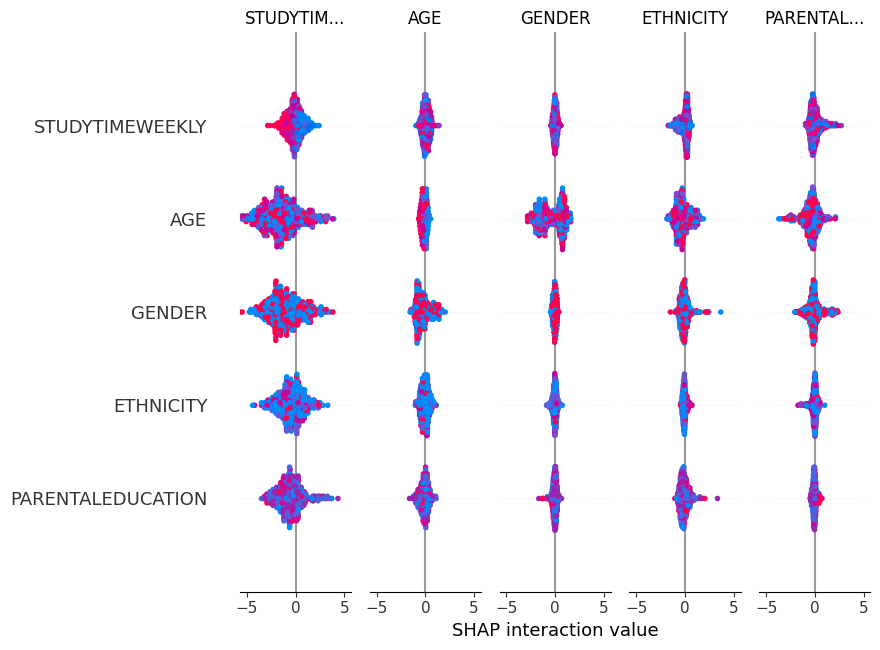

In [27]:
shap.summary_plot(
    shap_values,
    training_model_test,
    feature_names = training_model_test.columns,
    show = False
)
plt.tight_layout()
plt.savefig("Global_summary.png", dpi = 300, bbox_inches = "tight")
plt.show

### 10.1 Key SHAP Findings
- **Absences** emerged as the dominant predictor across all grade classes
- Confirms EDA finding — correlation analysis and SHAP independently agree
- **StudyTimeWeekly** and **ParentalSupport** are next most impactful
- Demographic features (Age, Gender, Ethnicity) show near-zero SHAP values
- Behavioural factors outweigh demographic background in predicting academic outcomes

In [28]:
importance = pd.DataFrame({
    'feature': training_model_train.columns,
    'Importance': xgb_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance)

              feature  Importance
5            ABSENCES    0.261206
6            TUTORING    0.100277
7     PARENTALSUPPORT    0.088257
9              SPORTS    0.072896
10              MUSIC    0.070999
11       VOLUNTEERING    0.070512
8     EXTRACURRICULAR    0.066352
4     STUDYTIMEWEEKLY    0.061850
2           ETHNICITY    0.054292
1              GENDER    0.053774
3   PARENTALEDUCATION    0.051727
0                 AGE    0.047858


In [29]:
importance.to_csv(
    "XGBoost_feature_importance.csv",
    index=False
)


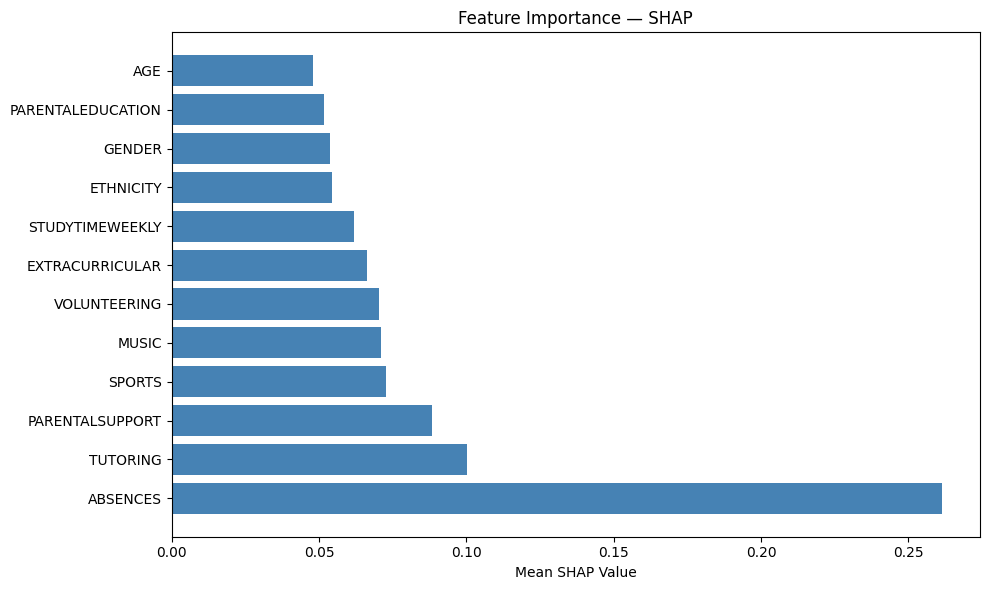

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV
fi = pd.read_csv('XGBoost_feature_importance.csv')  

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fi['feature'], fi['Importance'], color='steelblue')
plt.xlabel('Mean SHAP Value')
plt.title('Feature Importance — SHAP')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150)
plt.show()

## 11. Conclusion
This pipeline demonstrates that student academic performance can be predicted 
with 69% accuracy and 0.853 ROC-AUC using purely behavioural features.

SHAP analysis confirms Absences as the strongest predictor, 
with StudyTimeWeekly and ParentalSupport as secondary factors.
Demographic features contribute minimally — suggesting interventions 
should focus on attendance and study habits rather than background characteristics.